In [12]:
filename = 'example2.jpg'
img = cv2.imread(filename)
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

# 2

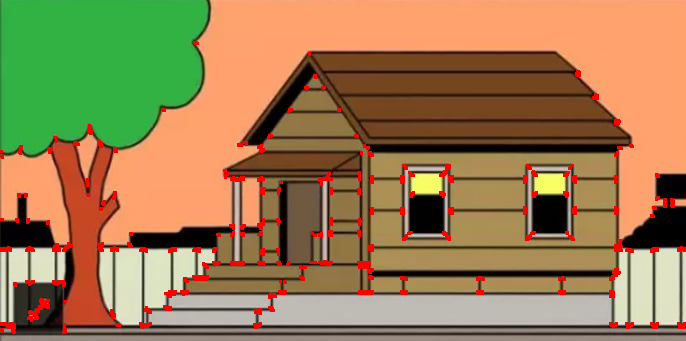

In [13]:
from google.colab.patches import cv2_imshow

gray = np.float32(gray)
dst = cv2.cornerHarris(gray,2,3,0.04)

#result is dilated for marking the corners, not important
dst = cv2.dilate(dst,None)

# Threshold for an optimal value, it may vary depending on the image.
img[dst>0.01*dst.max()]=[0,0,255]

cv2_imshow(img)


# 3

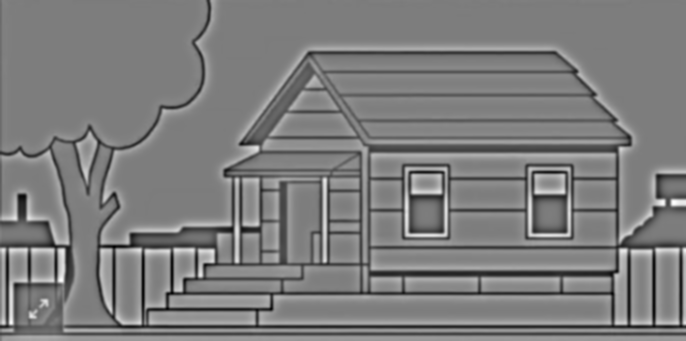

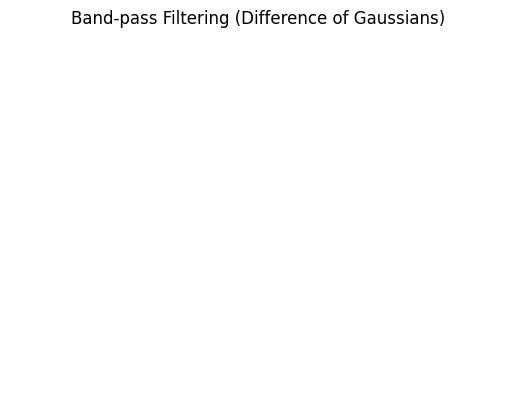

In [18]:

sigma1 = 1.0
sigma2 = 5.0

blurred1 = cv2.GaussianBlur(gray, (0, 0), sigma1)
blurred2 = cv2.GaussianBlur(gray, (0, 0), sigma2)

dog_filtered_image = blurred1 - blurred2

dog_filtered_image_norm = cv2.normalize(dog_filtered_image, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

from google.colab.patches import cv2_imshow
cv2_imshow(dog_filtered_image_norm)
plt.title('Band-pass Filtering (Difference of Gaussians)')
plt.axis('off')
plt.show()

# 4

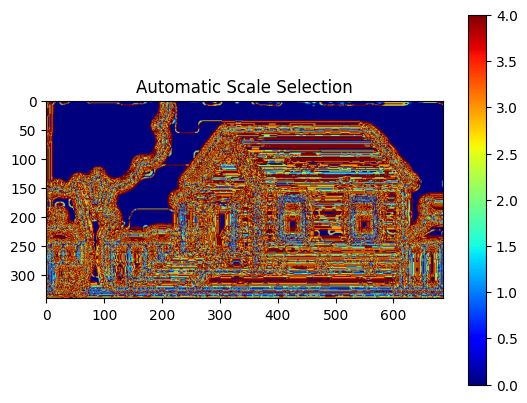

In [20]:
img = cv2.imread("example2.jpg", cv2.IMREAD_GRAYSCALE)
scales = [1, 2, 3, 4, 5]

responses = []

for sigma in scales:

    # Gaussian blur
    blur = cv2.GaussianBlur(img, (0,0), sigma)

    # Laplacian
    lap = cv2.Laplacian(blur, cv2.CV_64F)

    # scale normalized response
    response = (sigma**2) * np.abs(lap)

    responses.append(response)

# stack responses
responses = np.stack(responses, axis=-1)

# chọn scale lớn nhất tại mỗi pixel
best_scale = np.argmax(responses, axis=-1)

plt.imshow(best_scale, cmap="jet")
plt.title("Automatic Scale Selection")
plt.colorbar()
plt.show()

# 5

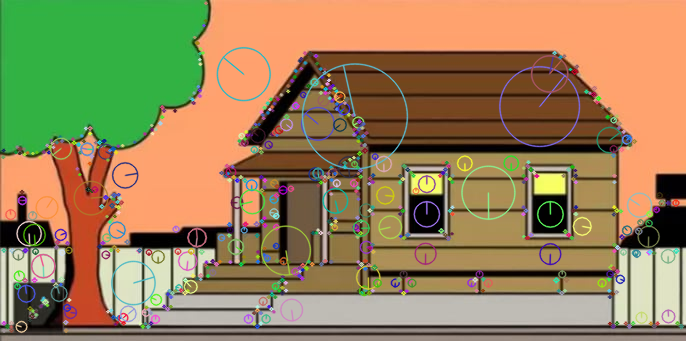

In [23]:
# đọc ảnh
img = cv2.imread("example2.jpg")

# chuyển sang grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# tạo SIFT detector
sift = cv2.SIFT_create()

# phát hiện keypoints
keypoints, descriptors = sift.detectAndCompute(gray, None)

# vẽ keypoints lên ảnh
img_kp = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# hiển thị kết quả
from google.colab.patches import cv2_imshow
cv2_imshow(img_kp)

# 6

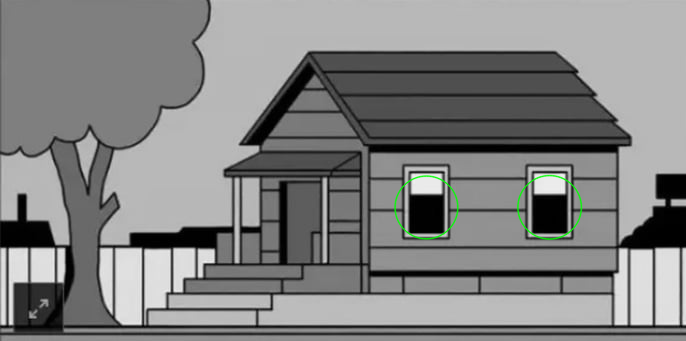

In [28]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("example2.jpg", cv2.IMREAD_GRAYSCALE)

params = cv2.SimpleBlobDetector_Params()

params.filterByArea = True
params.minArea = 50

detector = cv2.SimpleBlobDetector_create(params)

keypoints = detector.detect(img)

output = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    (0,255,0),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

cv2_imshow(output)

# 7

Number of keypoints: 879
Descriptor shape: (879, 128)


(np.float64(-0.5), np.float64(685.5), np.float64(340.5), np.float64(-0.5))

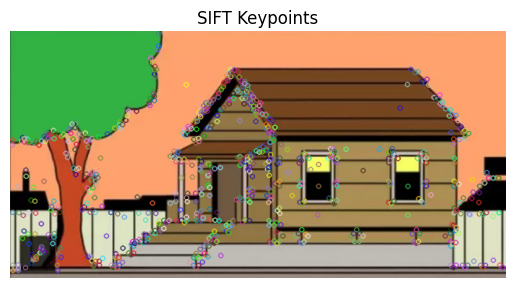

In [29]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# đọc ảnh
img = cv2.imread("example2.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# SIFT feature detector
sift = cv2.SIFT_create()

keypoints, descriptors = sift.detectAndCompute(gray, None)

print("Number of keypoints:", len(keypoints))
print("Descriptor shape:", descriptors.shape)

# K-means tạo visual words
K = 20
kmeans = KMeans(n_clusters=K, random_state=0)
kmeans.fit(descriptors)

centers = kmeans.cluster_centers_

# hiển thị keypoints
img_kp = cv2.drawKeypoints(img, keypoints, None)

plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
plt.title("SIFT Keypoints")
plt.axis("off")

Bag of Words Histogram:
[43. 36. 66. 70. 42. 48. 42. 61. 23. 30. 33. 34. 51. 28. 21. 70. 58. 26.
 35. 62.]


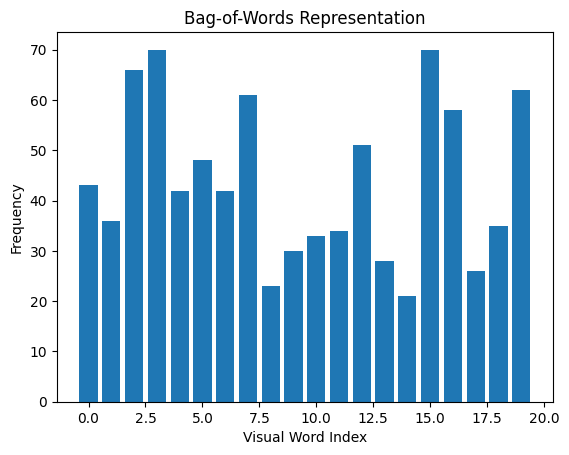

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def build_histogram(des, centers):

    hist = np.zeros(len(centers))

    for d in des:
        distances = np.linalg.norm(centers - d, axis=1)
        idx = np.argmin(distances)
        hist[idx] += 1

    return hist


# tạo histogram BoW
histogram = build_histogram(descriptors, centers)

print("Bag of Words Histogram:")
print(histogram)

# vẽ histogram
plt.bar(range(len(histogram)), histogram)
plt.title("Bag-of-Words Representation")
plt.xlabel("Visual Word Index")
plt.ylabel("Frequency")
plt.show()

# 8

Good matches: 32


(np.float64(-0.5), np.float64(1385.5), np.float64(799.5), np.float64(-0.5))

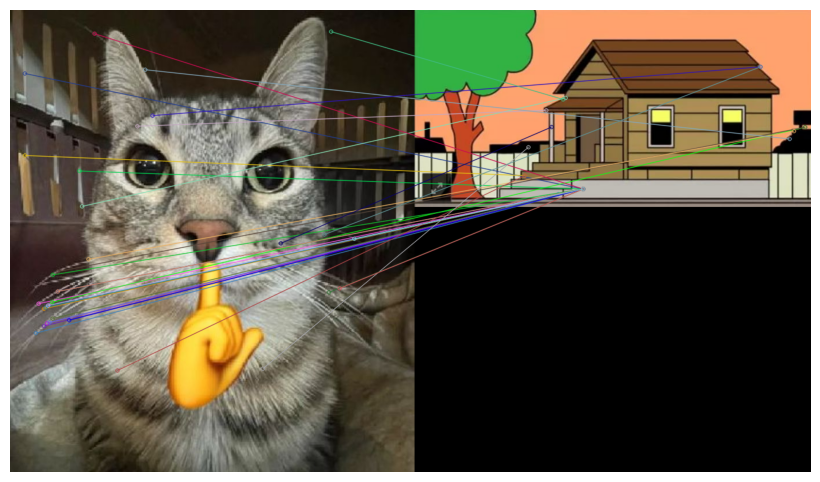

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# đọc 2 ảnh
img1 = cv2.imread("example.jpg")
img2 = cv2.imread("example2.jpg")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# SIFT
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# BF matcher
bf = cv2.BFMatcher()

matches = bf.knnMatch(des1, des2, k=2)

good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)

print("Good matches:", len(good))

# hiển thị matching
img_match = cv2.drawMatches(img1, kp1, img2, kp2, good[:40], None, flags=2)

plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(img_match, cv2.COLOR_BGR2RGB))
plt.axis("off")

(np.float64(-0.5), np.float64(1385.5), np.float64(799.5), np.float64(-0.5))

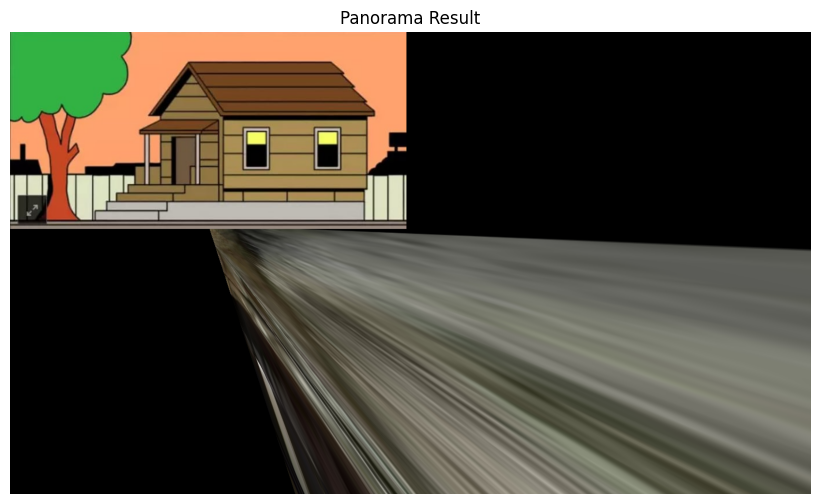

In [37]:
# lấy tọa độ keypoints
src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

# tính homography bằng RANSAC
H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

# kích thước panorama
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]

# warp ảnh 1
panorama = cv2.warpPerspective(img1, H, (w1 + w2, max(h1, h2)))

# đặt ảnh 2 vào bên trái
panorama[0:h2, 0:w2] = img2

# hiển thị kết quả
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
plt.title("Panorama Result")
plt.axis("off")

# 9

Good matches: 32


(np.float64(-0.5), np.float64(1385.5), np.float64(799.5), np.float64(-0.5))

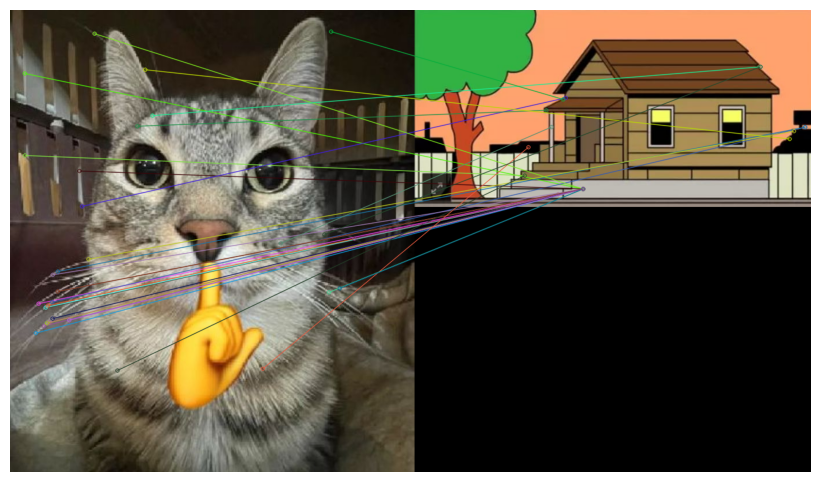

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# đọc 2 ảnh
img1 = cv2.imread("example.jpg")
img2 = cv2.imread("example2.jpg")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# SIFT
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# BFMatcher
bf = cv2.BFMatcher()

matches = bf.knnMatch(des1, des2, k=2)

good = []
for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append(m)

print("Good matches:", len(good))

# hiển thị matches
match_img = cv2.drawMatches(img1, kp1, img2, kp2, good[:40], None, flags=2)

plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

(np.float64(-0.5), np.float64(1385.5), np.float64(799.5), np.float64(-0.5))

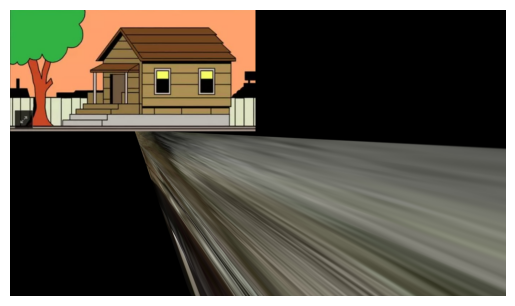

In [40]:
src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 4)

h1,w1 = img1.shape[:2]
h2,w2 = img2.shape[:2]

result = cv2.warpPerspective(img1, H, (w1+w2, h1))

result[0:h2,0:w2] = img2

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")

# 10

Good matches: 32


(np.float64(-0.5), np.float64(1385.5), np.float64(799.5), np.float64(-0.5))

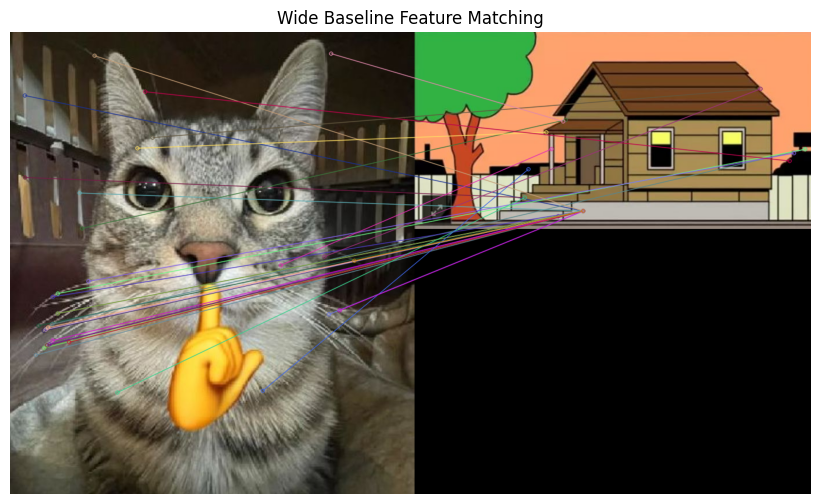

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# đọc ảnh
img1 = cv2.imread("example.jpg")
img2 = cv2.imread("example2.jpg")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# SIFT
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# BFMatcher
bf = cv2.BFMatcher()

matches = bf.knnMatch(des1, des2, k=2)

good = []
for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append(m)

print("Good matches:", len(good))

# hiển thị matching
match_img = cv2.drawMatches(img1, kp1, img2, kp2, good[:40], None, flags=2)

plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
plt.title("Wide Baseline Feature Matching")
plt.axis("off")

Fundamental Matrix:
[[-2.41780044e-06 -2.11239784e-06 -4.38222370e-04]
 [-1.06968712e-05 -8.04592198e-06 -1.32391865e-03]
 [ 9.86068532e-04  2.59761727e-03  1.00000000e+00]]


(np.float64(-0.5), np.float64(699.5), np.float64(799.5), np.float64(-0.5))

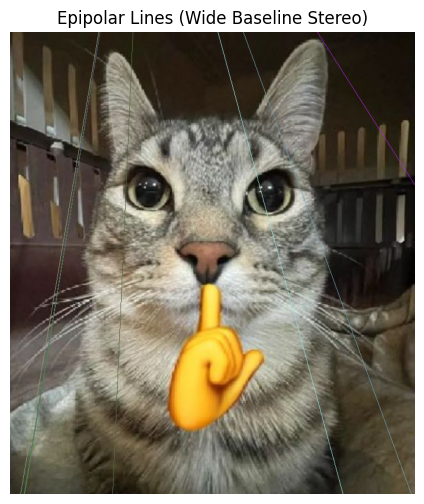

In [42]:
# lấy tọa độ keypoints
pts1 = np.float32([kp1[m.queryIdx].pt for m in good])
pts2 = np.float32([kp2[m.trainIdx].pt for m in good])

# tính Fundamental Matrix
F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC)

print("Fundamental Matrix:")
print(F)

# chọn inlier matches
pts1 = pts1[mask.ravel()==1]
pts2 = pts2[mask.ravel()==1]

# vẽ epipolar lines
lines = cv2.computeCorrespondEpilines(pts2.reshape(-1,1,2), 2, F)
lines = lines.reshape(-1,3)

img1_epi = img1.copy()

for r,pt in zip(lines, pts1):
    color = tuple(np.random.randint(0,255,3).tolist())
    x0,y0 = map(int,[0, -r[2]/r[1]])
    x1,y1 = map(int,[img1.shape[1], -(r[2]+r[0]*img1.shape[1])/r[1]])
    img1_epi = cv2.line(img1_epi,(x0,y0),(x1,y1),color,1)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(img1_epi, cv2.COLOR_BGR2RGB))
plt.title("Epipolar Lines (Wide Baseline Stereo)")
plt.axis("off")

#11

In [44]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("example2.jpg")

dataset = []

# tạo các biến thể của ảnh
dataset.append(img)
dataset.append(cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE))
dataset.append(cv2.GaussianBlur(img,(9,9),0))
dataset.append(cv2.convertScaleAbs(img, alpha=1.3, beta=20))
dataset.append(cv2.resize(img,None,fx=0.7,fy=0.7))

# trích xuất histogram
features = []

for im in dataset:

    hist = cv2.calcHist([im],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])
    hist = cv2.normalize(hist,hist).flatten()

    features.append(hist)

print("Dataset size:", len(dataset))

Dataset size: 5


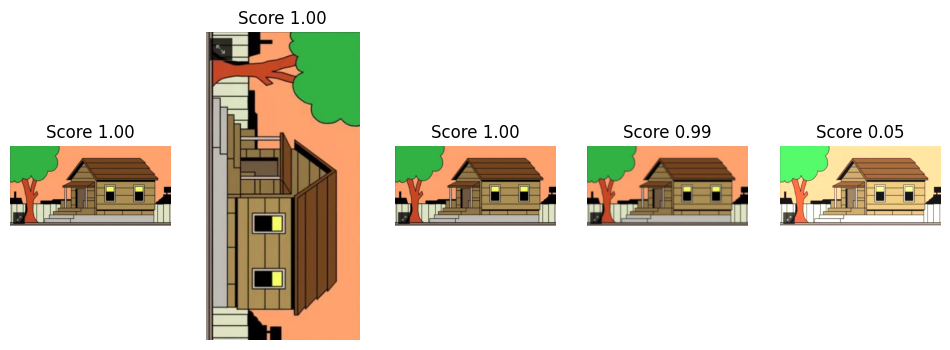

In [45]:
query = img.copy()

query_hist = cv2.calcHist([query],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])
query_hist = cv2.normalize(query_hist,query_hist).flatten()

scores = []

for f in features:
    score = cv2.compareHist(query_hist,f,cv2.HISTCMP_CORREL)
    scores.append(score)

scores = np.array(scores)

top_idx = scores.argsort()[::-1]

plt.figure(figsize=(12,4))

for i,idx in enumerate(top_idx):

    plt.subplot(1,len(dataset),i+1)
    plt.imshow(cv2.cvtColor(dataset[idx], cv2.COLOR_BGR2RGB))
    plt.title("Score %.2f" % scores[idx])
    plt.axis("off")

plt.show()

#12

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# đọc ảnh
img = cv2.imread("example2.jpg")

# tạo dataset từ 1 ảnh
dataset = []
dataset.append(img)
dataset.append(cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE))
dataset.append(cv2.GaussianBlur(img,(7,7),0))
dataset.append(cv2.convertScaleAbs(img, alpha=1.2, beta=30))
dataset.append(cv2.resize(img,None,fx=0.7,fy=0.7))

# SIFT
sift = cv2.SIFT_create()

descriptors_list = []

for im in dataset:

    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    kp, des = sift.detectAndCompute(gray, None)

    if des is not None:
        descriptors_list.append(des)

descriptors = np.vstack(descriptors_list)

print("Total descriptors:", descriptors.shape)

# KMeans → Visual words
K = 20

kmeans = KMeans(n_clusters=K, random_state=0)
kmeans.fit(descriptors)

centers = kmeans.cluster_centers_

Total descriptors: (3697, 128)


Histogram shape: (5, 20)


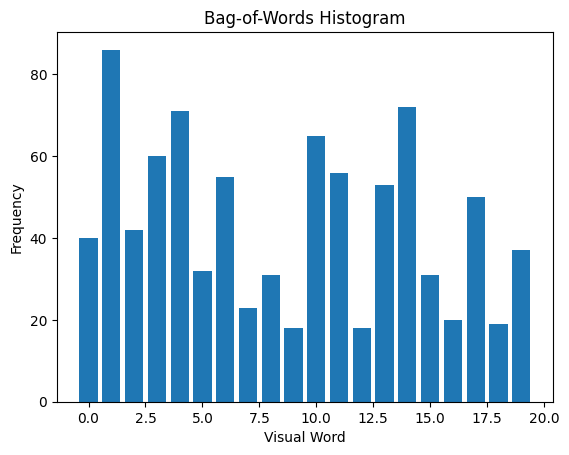

In [47]:
def build_histogram(des, centers):

    hist = np.zeros(len(centers))

    for d in des:
        dist = np.linalg.norm(centers - d, axis=1)
        idx = np.argmin(dist)
        hist[idx] += 1

    return hist


histograms = []

for im in dataset:

    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

    kp, des = sift.detectAndCompute(gray, None)

    if des is not None:
        hist = build_histogram(des, centers)
        histograms.append(hist)

histograms = np.array(histograms)

print("Histogram shape:", histograms.shape)

# hiển thị histogram của ảnh đầu
plt.bar(range(len(histograms[0])), histograms[0])
plt.title("Bag-of-Words Histogram")
plt.xlabel("Visual Word")
plt.ylabel("Frequency")
plt.show()
